In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl
import xlrd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
import math


In [2]:
df = pd.read_excel('../Data/fetal_health_base.xlsx')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

In [3]:
#visualizar duas colunas objects apenas
df[['mean_value_of_short_term_variability', 'mean_value_of_long_term_variability']].head()

,mean_value_of_short_term_variability,mean_value_of_long_term_variability
0,0.5,2026-04-02 00:00:00
1,2026-01-02 00:00:00,2026-04-10 00:00:00
2,2026-01-02 00:00:00,2026-04-13 00:00:00
3,2026-04-02 00:00:00,23.0
4,2026-04-02 00:00:00,2026-09-19 00:00:00


### Tratamento das colunas object
As duas colunas, se o valor foi 0 marcou como date. A partir disso vou fazer a troca desses valores para valores float64

In [4]:
#tirar o valor todo que tiver ...00:00:00... na sting e substituir por 0

colunas_alvo = ['mean_value_of_short_term_variability', 'mean_value_of_long_term_variability']

for coluna in colunas_alvo:
    teste = pd.to_datetime(df[coluna], errors='coerce', format='mixed')
    df[coluna] = df[coluna].mask(teste.notna(), 0)
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

#verificar se a substituição foi feita corretamente
display(df[['mean_value_of_short_term_variability', 'mean_value_of_long_term_variability']].head(10))
df.to_csv('../Data/fetal_health_base_limpa.csv', index=False)
df.info()

,mean_value_of_short_term_variability,mean_value_of_long_term_variability
0,0.5,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,23.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.5,0.0
8,0.5,0.0
9,0.3,0.0


<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

### Agora que não temos valores faltantes ou valores do tipo diferente, podemos ir para algumas análises das colunas

In [5]:
df["fetal_health"].value_counts(normalize=True)

fetal_health
1.0    0.778457
2.0    0.138758
3.0    0.082785
Name: proportion, dtype: float64

Desbalanceamento (esperado por ser um dataset clínico)

### Separando os dados para focar nos dados preditivos


In [6]:
y = df["fetal_health"]
X = df.drop(columns=["fetal_health"])
X.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,2.943321,8.108617,4.136167,1.818979,0.003293,0.158514,46.990122,0.352493,9.84666,...,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320
std,9.840844,3.745502,42.582101,2.886534,2.884175,0.057300,0.589948,17.192814,0.543229,18.39688,...,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.00000,...,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000
25%,126.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,32.000000,0.000000,0.00000,...,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000
50%,133.000000,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000,49.000000,0.000000,0.00000,...,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000
75%,140.000000,5.000000,2.000000,6.000000,3.000000,0.000000,0.000000,61.000000,0.600000,11.00000,...,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000
max,160.000000,19.000000,481.000000,15.000000,15.000000,1.000000,5.000000,87.000000,7.000000,91.00000,...,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000


In [7]:
X.head(10)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,120.0,0.0,0.0,0.00,0.0,0.0,0.0,73.0,0.5,43.0,...,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0
1,132.0,6.0,0.0,6.00,3.0,0.0,0.0,17.0,0.0,0.0,...,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0
2,133.0,3.0,0.0,8.00,3.0,0.0,0.0,16.0,0.0,0.0,...,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0
3,134.0,3.0,0.0,8.00,3.0,0.0,0.0,16.0,0.0,0.0,...,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0
4,132.0,7.0,0.0,8.00,0.0,0.0,0.0,16.0,0.0,0.0,...,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0
5,134.0,1.0,0.0,0.01,9.0,0.0,2.0,26.0,0.0,0.0,...,150.0,50.0,200.0,5.0,3.0,76.0,107.0,107.0,170.0,0.0
6,134.0,1.0,0.0,13.00,8.0,0.0,3.0,29.0,0.0,0.0,...,150.0,50.0,200.0,6.0,3.0,71.0,107.0,106.0,215.0,0.0
7,122.0,0.0,0.0,0.00,0.0,0.0,0.0,83.0,0.5,6.0,...,68.0,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0
8,122.0,0.0,0.0,2.00,0.0,0.0,0.0,84.0,0.5,5.0,...,68.0,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0
9,122.0,0.0,0.0,3.00,0.0,0.0,0.0,86.0,0.3,6.0,...,68.0,62.0,130.0,1.0,0.0,122.0,122.0,123.0,1.0,1.0


### A questão de outliers foi mantida tendo em vista que eles são importantes para visualizar e entender a classe dos Patológicos, pois podem ser um indicativo desta classe

### Vamos plotar como a distribuição dos dados se relacionam com a variável alvo

/tmp/ipykernel_18886/1912181037.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=X[col], hue=y, ax=axes[i])


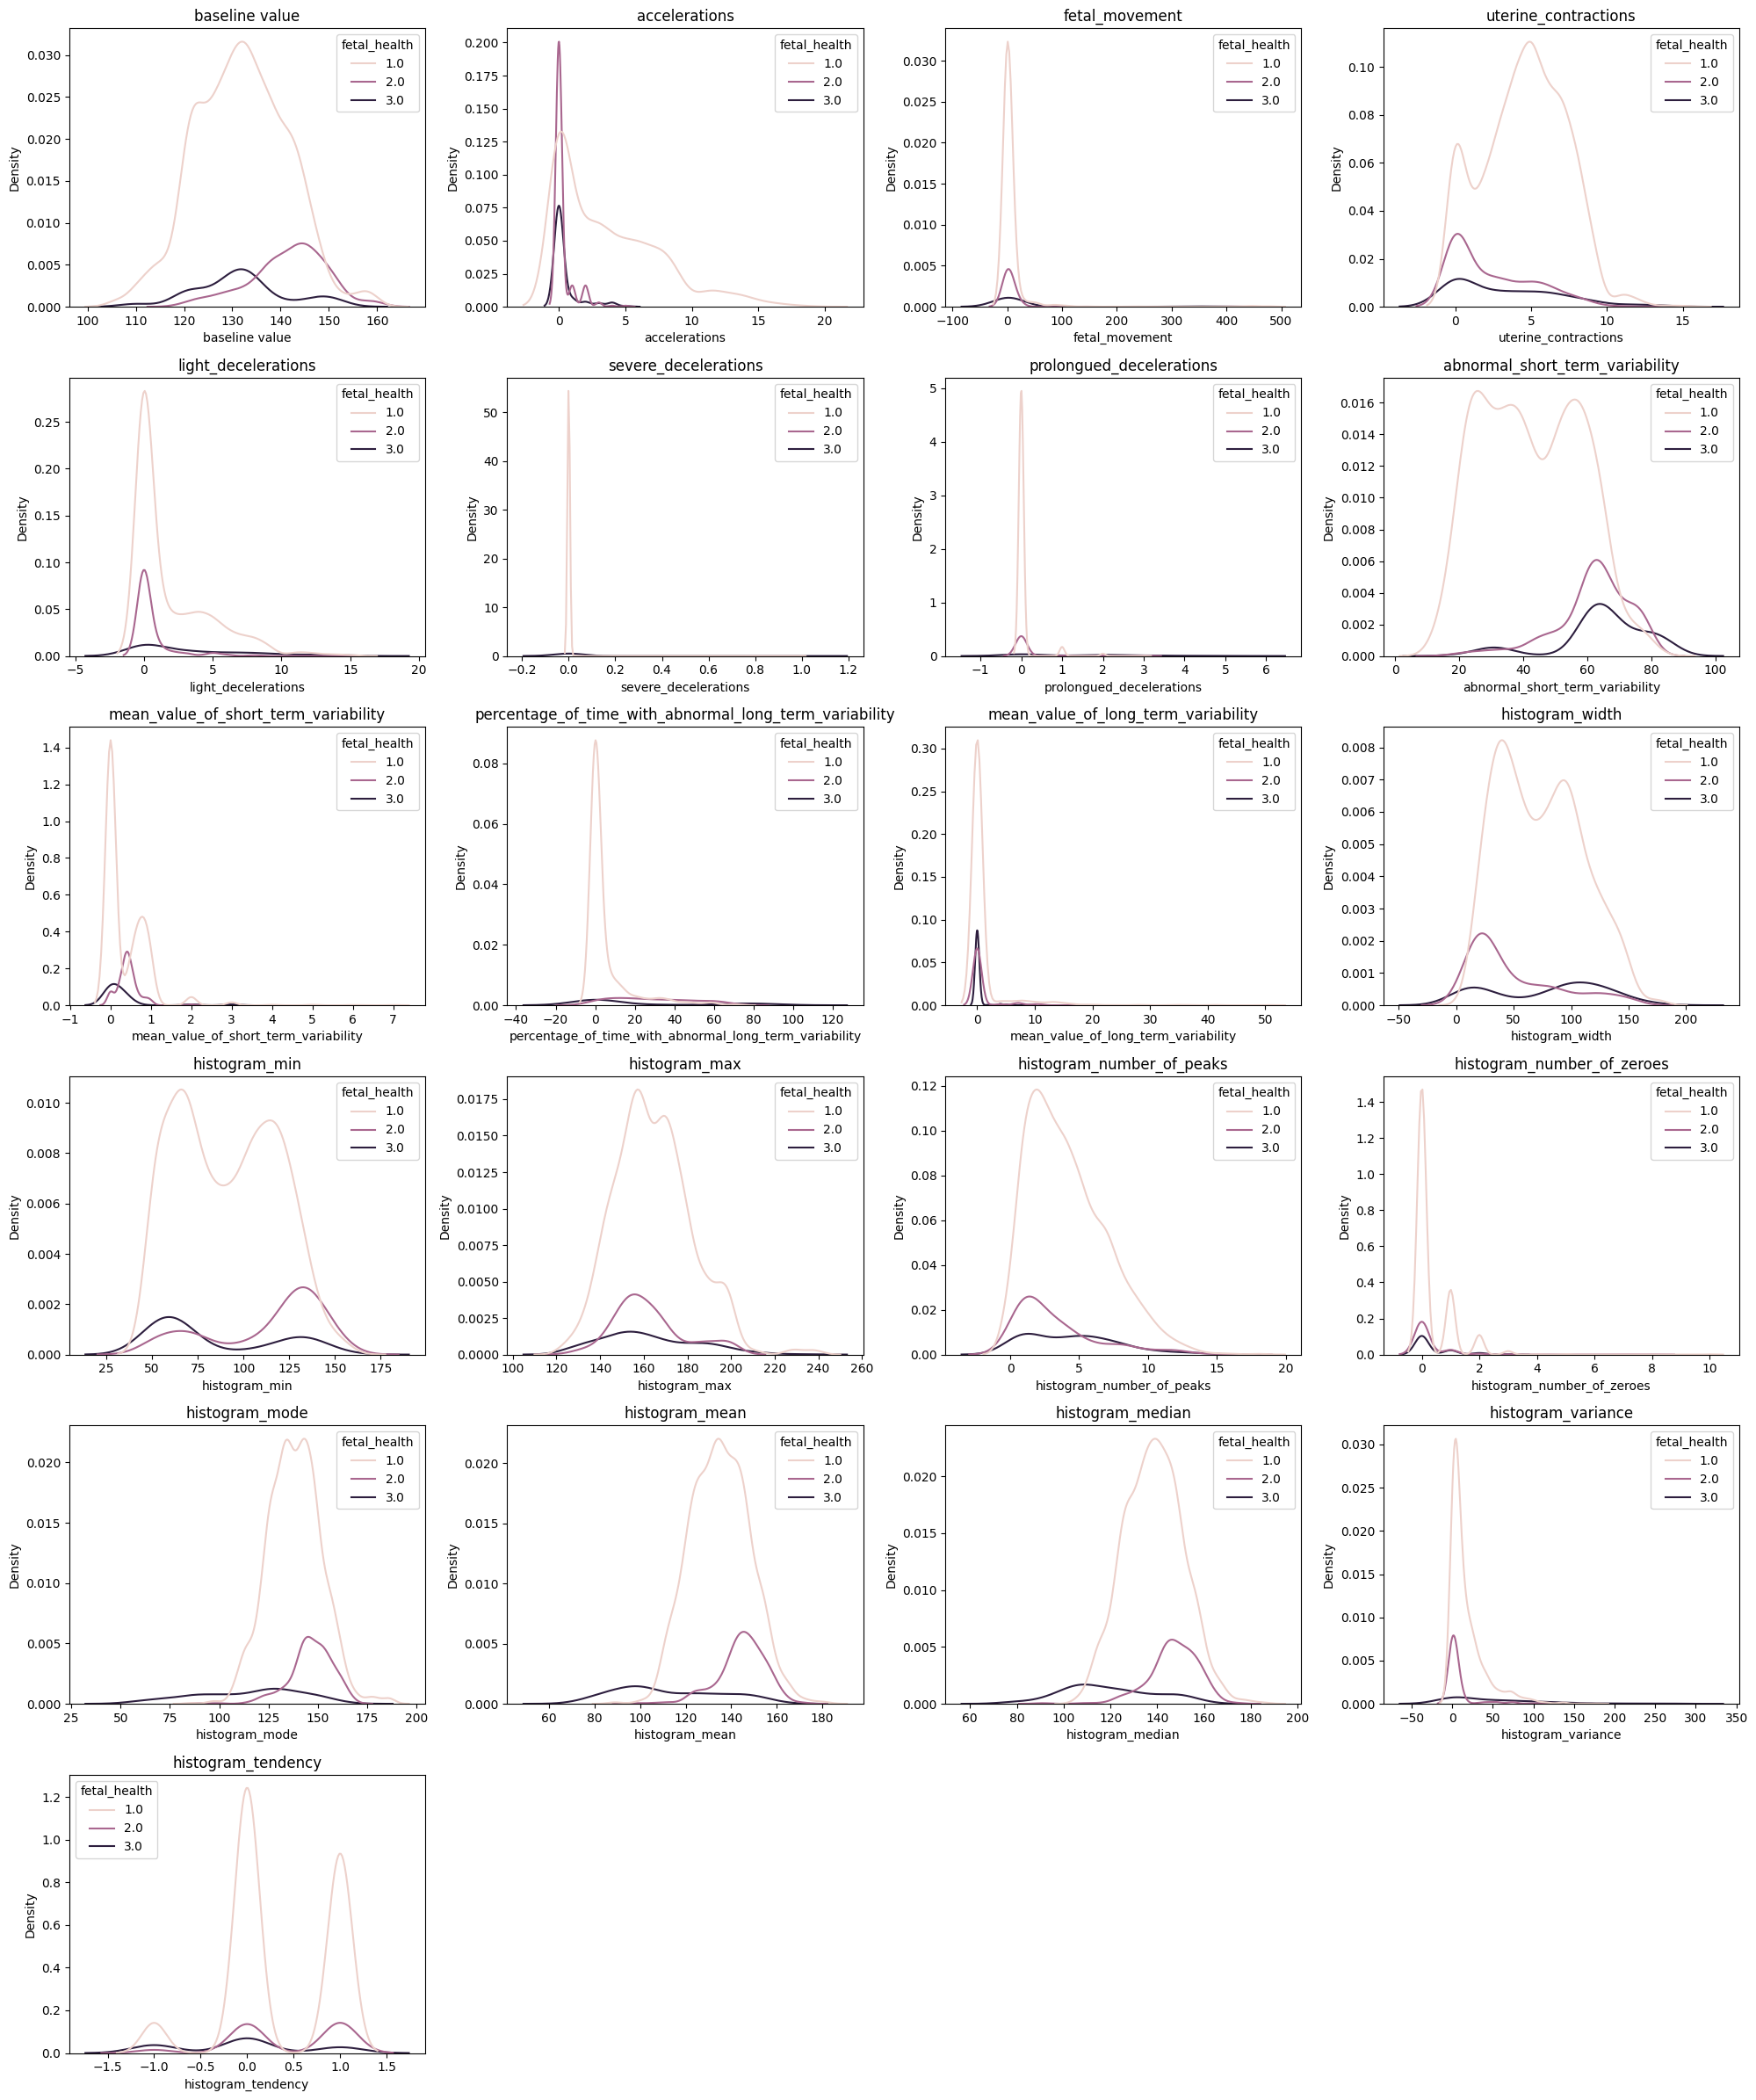

In [8]:


n_cols = 4                   
n_features = X.shape[1]       # 21
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.kdeplot(x=X[col], hue=y, ax=axes[i])
    axes[i].set_title(col)

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Vamos usar o SelectKbest para ver como (individualmente as variaveis preditivas explicam bem a variável alvo)

In [9]:
seletor = SelectKBest(score_func=f_classif, k=22)
seletor.fit(X, y)
seletor.get_feature_names_out()

/home/italocmb/Área de trabalho/Fetal-Health-Classification/venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=22 is greater than n_features=21. All the features will be returned.
  warnings.warn(


array(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations',
       'severe_decelerations', 'prolongued_decelerations',
       'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency'],
      dtype=object)

In [10]:

seletor_scores = dict(zip(X.columns, seletor.scores_))
seletor_scores_ordenados = dict(sorted(seletor_scores.items(), key=lambda item: item[1], reverse=True))
seletor_scores_ordenados

{'prolongued_decelerations': np.float64(505.85320558973643),
 'percentage_of_time_with_abnormal_long_term_variability': np.float64(345.15638462899693),
 'abnormal_short_term_variability': np.float64(343.82041888287506),
 'histogram_mean': np.float64(297.6254965744821),
 'histogram_mode': np.float64(275.11769591863845),
 'histogram_median': np.float64(248.77223746855066),
 'accelerations': np.float64(172.63875954604268),
 'histogram_variance': np.float64(150.79684903736657),
 'baseline value': np.float64(140.62107554189794),
 'histogram_min': np.float64(87.34050292981547),
 'uterine_contractions': np.float64(82.36415828683893),
 'histogram_width': np.float64(55.08824087912571),
 'light_decelerations': np.float64(54.758540422993775),
 'histogram_tendency': np.float64(44.54229403163807),
 'severe_decelerations': np.float64(28.44815598710158),
 'histogram_number_of_peaks': np.float64(12.104834133185133),
 'fetal_movement': np.float64(9.882346312168428),
 'mean_value_of_short_term_variabili

Observamos a partir deste métod que certas features (de modo comparativo) não explicam muito bem a variável alvo


### Usando uma árvore de decisão como outra validação para a remoção de features

In [11]:
arvore = DecisionTreeClassifier()
arvore.fit(X, y)
#colocar as features em ordem de importância com o nome da feature
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': arvore.feature_importances_
}).sort_values('importance', ascending=False)
feature_importance

,feature,importance
7,abnormal_short_term_variability,0.282275
9,percentage_of_time_with_abnormal_long_term_var...,0.209297
17,histogram_mean,0.143581
0,baseline value,0.063432
1,accelerations,0.050193
3,uterine_contractions,0.038701
18,histogram_median,0.035368
14,histogram_number_of_peaks,0.033324
6,prolongued_decelerations,0.029103
13,histogram_max,0.024899


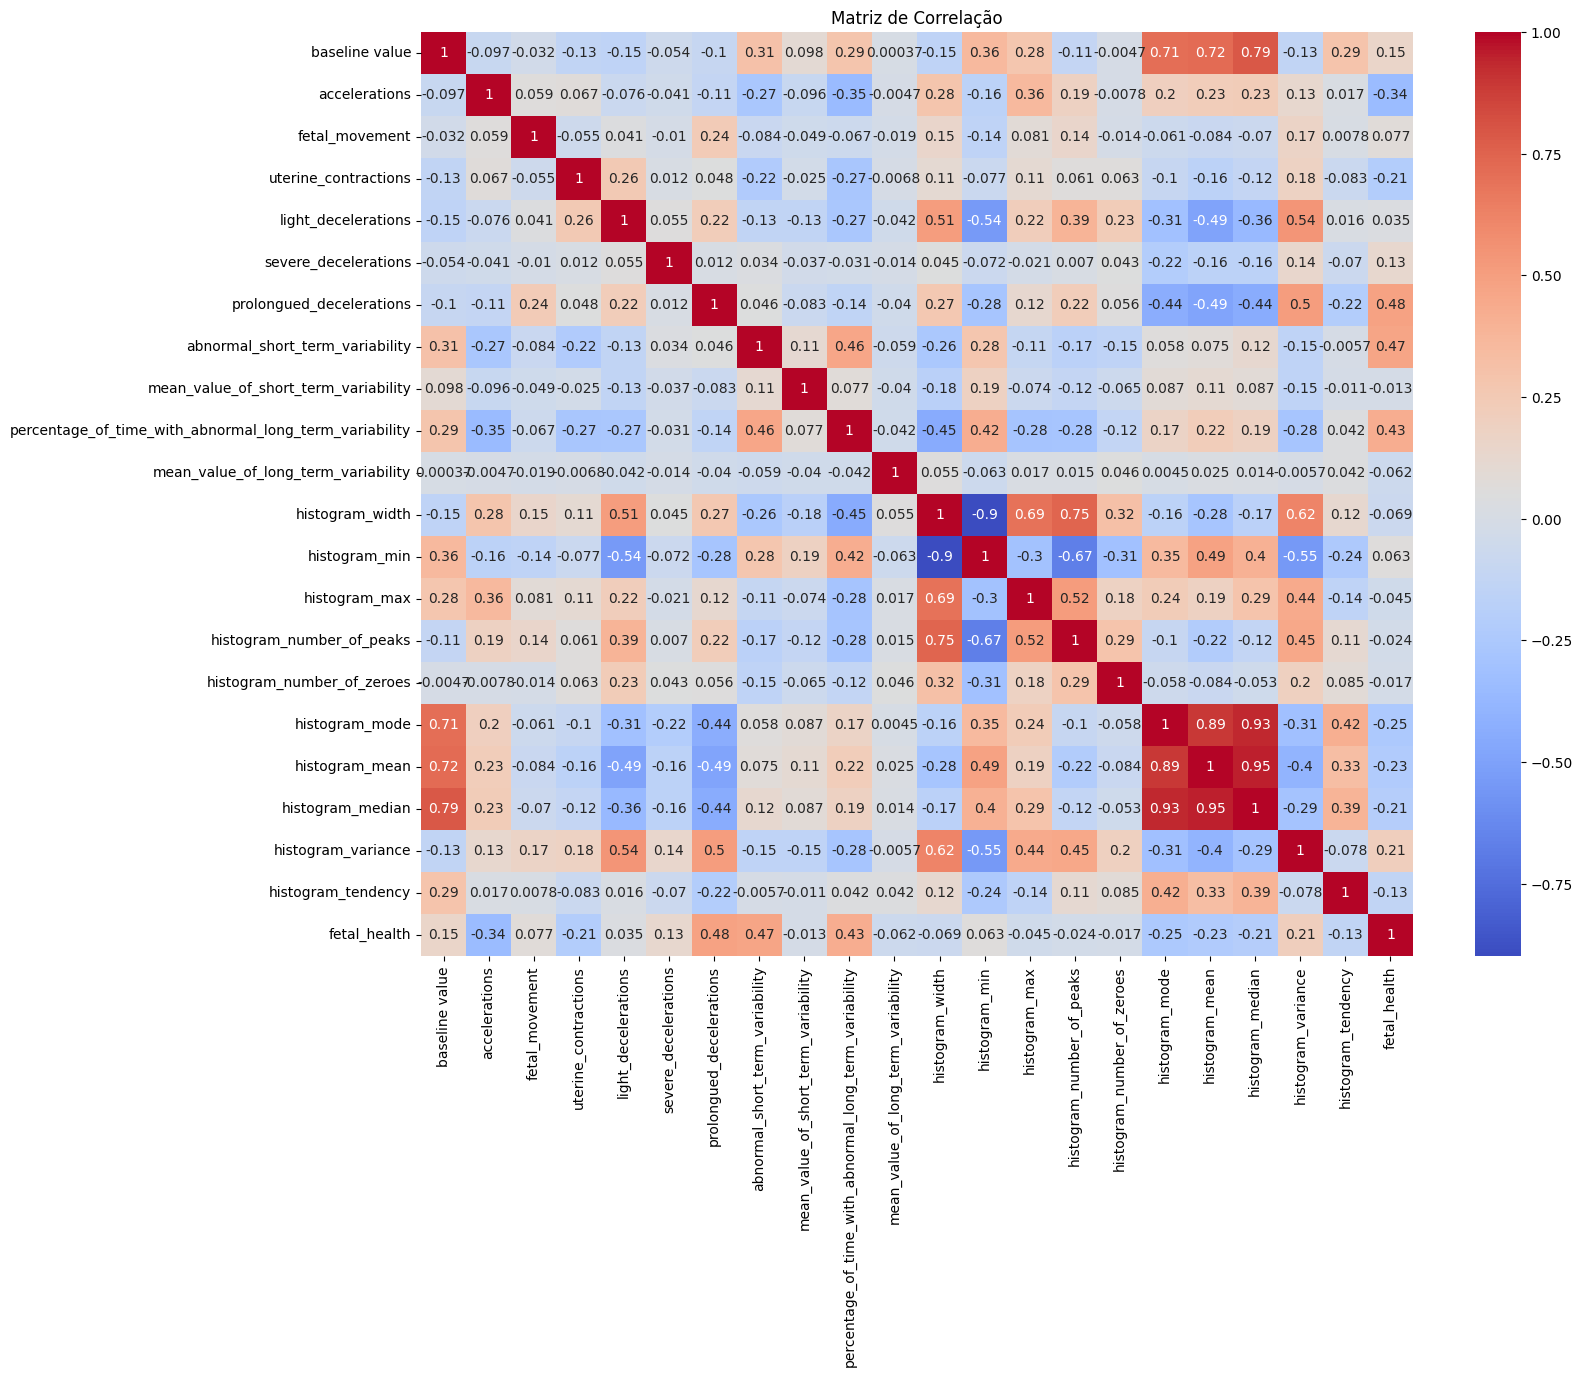

In [12]:
#printando a matriz de correlação entre as features com a variavel alvo
correlacao = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()



In [13]:
mi = mutual_info_classif(X, y, random_state=42)

pd.Series(mi, index=X.columns)\
    .sort_values(ascending=False)

percentage_of_time_with_abnormal_long_term_variability    0.203486
abnormal_short_term_variability                           0.199809
mean_value_of_short_term_variability                      0.187638
histogram_mean                                            0.170821
histogram_variance                                        0.157141
histogram_mode                                            0.146869
accelerations                                             0.137580
histogram_median                                          0.133541
baseline value                                            0.126841
histogram_width                                           0.123772
histogram_min                                             0.119963
prolongued_decelerations                                  0.100403
histogram_max                                             0.079081
uterine_contractions                                      0.066011
fetal_movement                                            0.05

## Agora vamos gerar 3 datasets, sendo: um conservador, intermediário e um outro mais agressivo
## Para fazer o treinamento nos 3, as vezes o mais agressivo com menos features pode apresentar um desempenho equivalente podendo ter mais generalização


In [14]:
# Essas variaveis foram claramente as menos importantes para explicar a variavel alvo, com base em todas as análises feitas
X_conservador = X.copy()
X_conservador = X_conservador.drop(columns=['histogram_number_of_zeroes', 'mean_value_of_long_term_variability'])
X_conservador.to_csv('../Data/dados_conservador.csv', index=False, sep=';')
print("Colunas: " + str(X_conservador.shape[1]))

X_intermediario = X_conservador.copy()
X_intermediario = X_intermediario.drop(columns=['severe_decelerations', 'histogram_number_of_peaks'])
X_intermediario.to_csv('../Data/dados_intermediario.csv', index=False, sep=';')
print("Colunas: " + str(X_intermediario.shape[1]))

#Essas variaveis de histograma tinham uma correlação absurdamente forte entre elas, por isso retirei apenas duas das 3 (deixei a histogram_mean, que apresentou as melhores métricas)
X_agressivo = X_intermediario.copy()
X_agressivo = X_agressivo.drop(columns=['histogram_mode', 'histogram_median', 'light_decelerations'])
X_agressivo.to_csv('../Data/dados_agressivo.csv', index=False, sep=';')
print("Colunas: " + str(X_agressivo.shape[1]))


Colunas: 19
Colunas: 17
Colunas: 14
